In [53]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns # iris(데이터프레임)가져오기
from sklearn import datasets # iris(X와 Y가 분리되서 numpy)가져오기
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt

```
- 데이터셋 생성 및 전처리
    X, y(라벨인코딩)분리 -> train_test_split분리(8:2)
- 모델 구성(입력4, 출력3, layer : 4 -> 64 -> 128 -> 50 -> 30 -> 3)
- 학습과정 설정 (loss='sparse_categorical_crossentropy')
- 학습
- 모델평가(가장 최선의 모델을 get)
- 모델 사용(저장 / 예측)
```
# 1. 기본적인 DNN
## 1. 데이터 셋 생성 및 전처리

In [5]:
iris = sns.load_dataset('iris')
iris['species'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [9]:
iris_X = iris.iloc[:, :-1].values
labelEncoder = LabelEncoder()
iris_y = labelEncoder.fit_transform(iris.iloc[:, -1])
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [11]:
iris = datasets.load_iris()
iris_X = iris.data
iris_y = iris.target
print(iris.target_names)
iris_X.shape, iris_y.shape

['setosa' 'versicolor' 'virginica']


((150, 4), (150,))

In [15]:
# 학습셋과 테스트셋 분리
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                    test_size=0.2,
                                                    stratify=iris_y)
np.c_[pd.Series(iris_y).value_counts(normalize=True),
      pd.Series(train_y).value_counts(normalize=True),
      pd.Series(test_y).value_counts(normalize=True)]

array([[0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333]])

In [14]:
np.c_[pd.Series(iris_y).value_counts(normalize=True),
      pd.Series(train_y).value_counts(normalize=True),
      pd.Series(test_y).value_counts(normalize=True)]

array([[0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333]])

## 2. 모델 구성 및 학습
- 4 -> 64 -> 128 -> 50 -> 30 -> 3
- He초기화, 다양한activation, 배치정규화, L2정규화, Dropout

In [20]:
model = Sequential([
    Input(4),
    Dense(units=64, activation='relu'),
    Dense(units=128, activation='relu'),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax'),
], name='sequential')
# model = Sequential(name='sequential')
# model.add(Input(4))
# model.add(Dense(units=64, activation='relu'))
# model.add(Dense(units=128, activation='relu'))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 64)                320       
                                                                 
 dense_16 (Dense)            (None, 128)               8320      
                                                                 
 dense_17 (Dense)            (None, 50)                6450      
                                                                 
 dense_18 (Dense)            (None, 30)                1530      
                                                                 
 dense_19 (Dense)            (None, 3)                 93        
                                                                 
Total params: 16,713
Trainable params: 16,713
Non-trainable params: 0
_________________________________________________________________


In [30]:
%%time
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
earlystopping = EarlyStopping(patience=40)

model_save_folder = 'model/'
import os
if not os.path.exists(model_save_folder):
    os.mkdir(model_save_folder)
file = model_save_folder + 'iris-{epoch:03d}-loss{val_loss:.4f}-acc{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(monitor='val_accuracy',
                             filepath=file, # 모델 저장 파일
                             save_best_only=True, # 모니터 지표가 개선된 경우만 모델 저장
                             mode='max',
                             verbose=1) # 저장 여부 로그 출력

hist = model.fit(train_X, train_y,
                 epochs=200,
                 validation_split=0.1,
                 callbacks=[earlystopping, checkpoint],
                 verbose=2)

Epoch 1/200

Epoch 1: val_accuracy improved from -inf to 1.00000, saving model to model\iris-001-loss0.0128-acc1.0000.h5
4/4 - 1s - loss: 0.1100 - accuracy: 0.9444 - val_loss: 0.0128 - val_accuracy: 1.0000 - 831ms/epoch - 208ms/step
Epoch 2/200

Epoch 2: val_accuracy did not improve from 1.00000
4/4 - 0s - loss: 0.1456 - accuracy: 0.9630 - val_loss: 0.0250 - val_accuracy: 1.0000 - 53ms/epoch - 13ms/step
Epoch 3/200

Epoch 3: val_accuracy did not improve from 1.00000
4/4 - 0s - loss: 0.0782 - accuracy: 0.9722 - val_loss: 0.4953 - val_accuracy: 0.8333 - 42ms/epoch - 10ms/step
Epoch 4/200

Epoch 4: val_accuracy did not improve from 1.00000
4/4 - 0s - loss: 0.0927 - accuracy: 0.9630 - val_loss: 0.0977 - val_accuracy: 0.9167 - 34ms/epoch - 9ms/step
Epoch 5/200

Epoch 5: val_accuracy did not improve from 1.00000
4/4 - 0s - loss: 0.0709 - accuracy: 0.9722 - val_loss: 0.0432 - val_accuracy: 1.0000 - 38ms/epoch - 10ms/step
Epoch 6/200

Epoch 6: val_accuracy did not improve from 1.00000
4/4 - 0s

## 3. 모델 평가

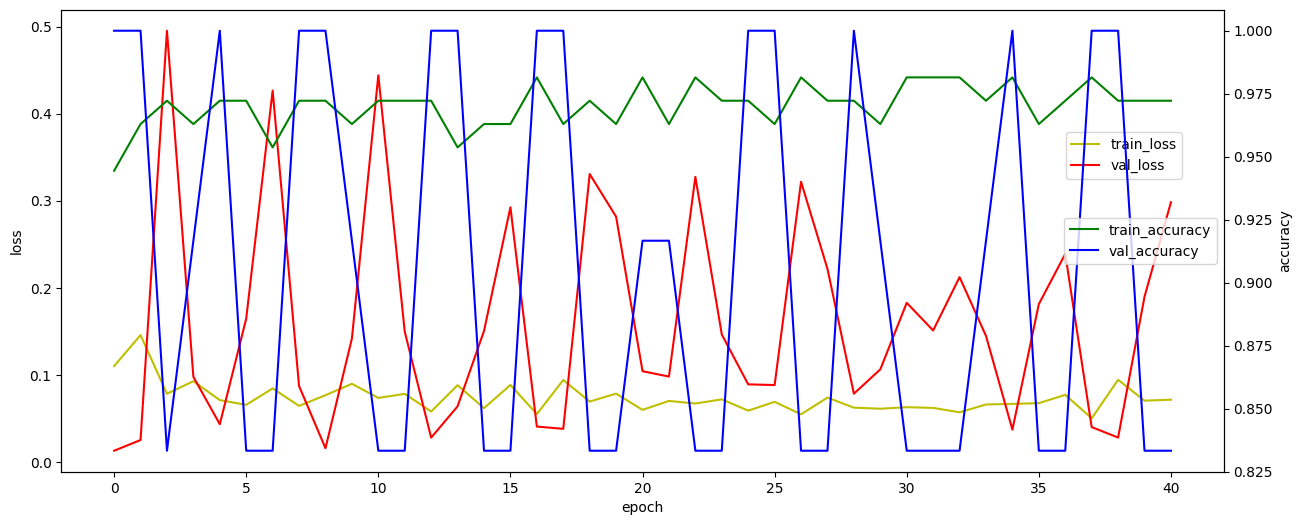

In [31]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [32]:
# 모델 평가
loss, acc = model.evaluate(test_X, test_y)
print(loss, acc)

1/1 [==============================] - 0s 20ms/step - loss: 0.0550 - accuracy: 0.9667
0.05500587448477745 0.9666666388511658


In [35]:
# 저장된 모델중 최선 모델
model1 = load_model('model/iris-001-loss0.0128-acc1.0000.h5')
loss1, acc1 = model1.evaluate(test_X, test_y)
print(loss1, acc1)

1/1 [==============================] - 0s 122ms/step - loss: 0.1036 - accuracy: 0.9667
0.10361150652170181 0.9666666388511658


# 2. sklearn 이용
- 4 -> 64 -> 128 -> 50 -> 30 -> 3

In [37]:
from sklearn.neural_network import MLPClassifier
# 1. 데이터
train_X.shape, train_y.shape, test_X.shape, test_y.shape 

((120, 4), (120,), (30, 4), (30,))

In [38]:
model = MLPClassifier(hidden_layer_sizes=(64, 128, 50, 30),
                      activation='relu',
                      solver='adam',
                      batch_size=40,
                      early_stopping=True,
                      n_iter_no_change=50, 
                      validation_fraction=0.1,
                      max_iter=200,
                      warm_start=True)

In [39]:
model.fit(train_X, train_y)

MLPClassifier(batch_size=40, early_stopping=True,
              hidden_layer_sizes=(64, 128, 50, 30), n_iter_no_change=50,
              warm_start=True)

In [40]:
# 4. 모델 평가
model.score(test_X, test_y)

1.0

In [43]:
# 5. 교차표(혼동행렬)
# 실제값 : test_y
y_hat = model.predict(test_X)
pd.crosstab(test_y, y_hat, rownames=['real'], colnames=['predict'])

predict,0,1,2
real,,,
0,10,0,0
1,0,10,0
2,0,0,10


In [44]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score

In [45]:
confusion_matrix(test_y, y_hat)

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]], dtype=int64)

# 3. 클래스를 생성하여 모델 생성함수 사용

In [46]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', output_dim=3, optimizer='adam'):
        # 모델 구성
        model = Sequential(layers=[
            Input(input_dim),
            Dense(units=50, activation=activation),
            Dense(units=30, activation=activation),
            Dense(units=output_dim, activation='softmax')
        ], name='sequential')
        # 모델 학습 설정
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer=optimizer,
                     metrics=['accuracy'])
        # 모델 return
        return model

In [47]:
%%time
# 1. 데이터
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)
# 2. 모델
model = DNNClassifier.build(input_dim=4, activation='relu', output_dim=3, optimizer='adam')
# 3. 모델 학습
hist = model.fit(train_X, train_y,
                epochs=50, 
                validation_split=0.1, 
                verbose=0)

(120, 4) (120,) (30, 4) (30,)
CPU times: total: 3.48 s
Wall time: 2.94 s


In [48]:
# 모델 평가
loss, accuracy = model.evaluate(test_X, test_y, verbose=0)
print(f'정확도 : {accuracy*100}%')

정확도 : 100.0%


# 4. 함수형API
- 병렬처리, Residual block

In [49]:
# 기존 model 스타일1
model = Sequential(layers=[
    Input(shape=(4,)),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax'),
])
# 기존 model 스타일2
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=3, activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_26 (Dense)            (None, 50)                250       
                                                                 
 dense_27 (Dense)            (None, 30)                1530      
                                                                 
 dense_28 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [50]:
# 함수형 API 스타일
from tensorflow.keras import Model
input_ = Input(shape=(4,))
layer1 = Dense(units=50, activation='relu')(input_)
layer2 = Dense(units=30, activation='relu')(layer1)
output = Dense(units=3, activation='softmax')(layer2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 4)]               0         
                                                                 
 dense_29 (Dense)            (None, 50)                250       
                                                                 
 dense_30 (Dense)            (None, 30)                1530      
                                                                 
 dense_31 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [51]:
# 4->160->3
# 기존의 model 방식
model = Sequential([
    Input(shape=(4,)),
    Dense(units=160, activation='relu'),
    Dense(units=3, activation='softmax')
])
# 함수형 API 방식
input_ = Input(shape=(4,))
layer  = Dense(units=160, activation='relu')(input_)
output = Dense(units=3,   activation='softmax')(layer)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_11 (InputLayer)       [(None, 4)]               0         
                                                                 
 dense_34 (Dense)            (None, 160)               800       
                                                                 
 dense_35 (Dense)            (None, 3)                 483       
                                                                 
Total params: 1,283
Trainable params: 1,283
Non-trainable params: 0
_________________________________________________________________


In [52]:
# 4->160->3를 병렬처리 방식
from tensorflow.keras.layers import concatenate
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=80, activation='relu')(input_)
dense3 = Dense(units=30, activation='relu')(input_)
x      = concatenate([dense1, dense2, dense3])
output = Dense(units=3, activation='softmax')(x)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_12 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_36 (Dense)               (None, 50)           250         ['input_12[0][0]']               
                                                                                                  
 dense_37 (Dense)               (None, 80)           400         ['input_12[0][0]']               
                                                                                                  
 dense_38 (Dense)               (None, 30)           150         ['input_12[0][0]']               
                                                                                            

In [54]:
# 레지듀얼 블럭(Residual Block)
from tensorflow.keras.layers import add
input_ = Input(shape=(4,))
dense1 = Dense(units=50, activation='relu')(input_)
layer1 = Dense(units=64, activation='relu')(dense1)
layer2 = Dense(units=50, activation='relu')(layer1)
dense2 = add([dense1, layer2])
output = Dense(units=3, activation='softmax')(dense2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_13 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_40 (Dense)               (None, 50)           250         ['input_13[0][0]']               
                                                                                                  
 dense_41 (Dense)               (None, 64)           3264        ['dense_40[0][0]']               
                                                                                                  
 dense_42 (Dense)               (None, 50)           3250        ['dense_41[0][0]']               
                                                                                            